# E Labs Data Analysis Tasks

## 📈 Task 2: Univariate Linear Regression using Gradient Descent


**SUBMITTED BY:**  Ampa Ranjan  
 

---

### Objective

The objective of this task is to build a Univariate Linear Regression model from scratch using NumPy and Gradient Descent without using Scikit-Learn regression functions.

This notebook includes:

- Data Cleaning
- Exploratory Data Analysis
- Correlation Analysis
- Feature Selection
- Gradient Descent Implementation
- Model Evaluation
- Visualization

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

df = pd.read_csv('student-mat.csv', sep=';')

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


# 📊 Dataset Overview

In [5]:
print("Shape:", df.shape)

df.info()

Shape: (395, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    objec

In [6]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


# 🔍 Missing Value Analysis

In [7]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

# 📈 Exploratory Data Analysis

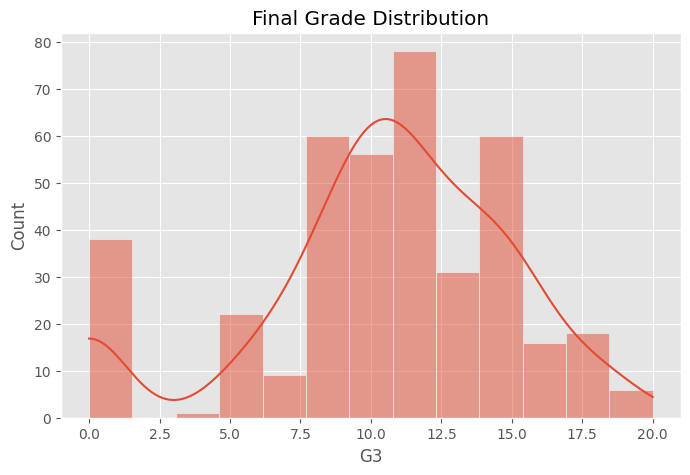

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['G3'], kde=True)

plt.title("Final Grade Distribution")
plt.show()

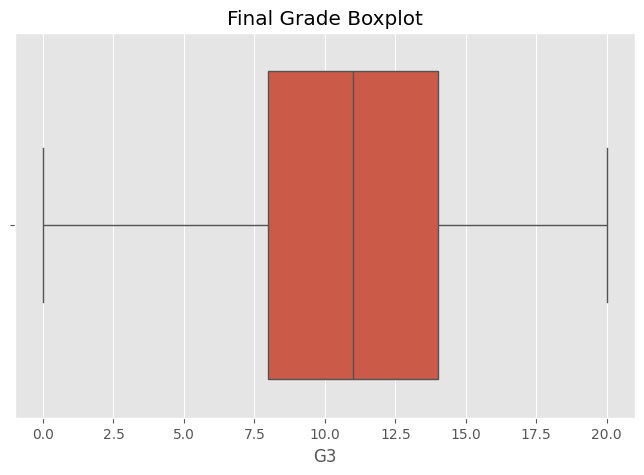

In [10]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['G3'])

plt.title("Final Grade Boxplot")
plt.show()

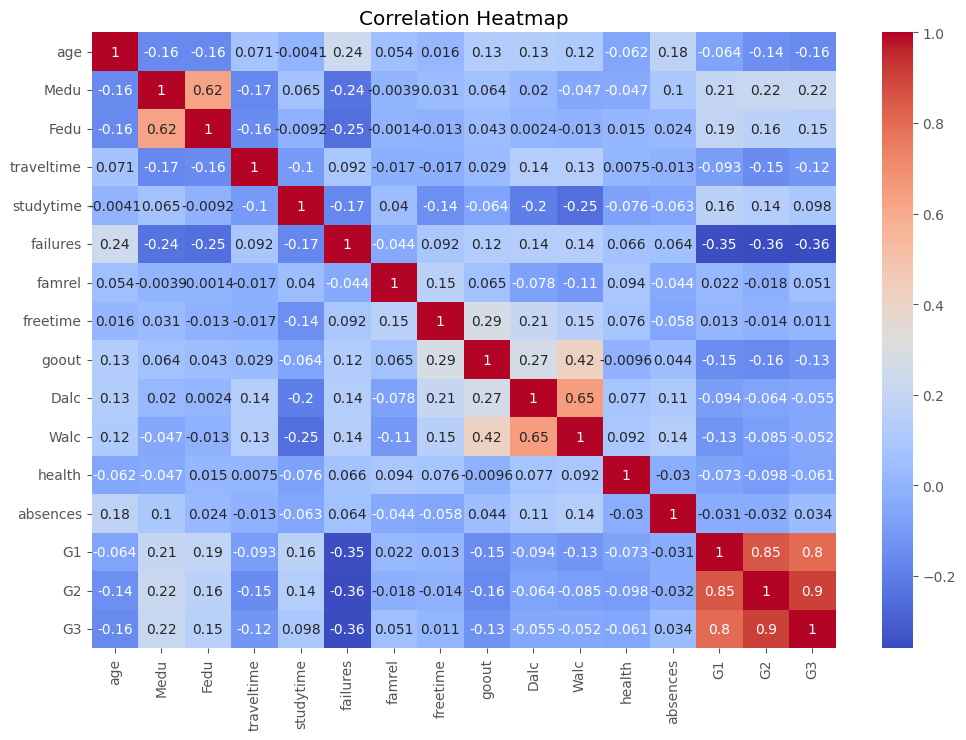

In [11]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(),annot=True,cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

# 🎯 Feature Selection

For univariate regression we select the feature with highest correlation with final grade (G3).

In [12]:
corr = numeric_df.corr()['G3'].sort_values(ascending=False)

print(corr)

G3            1.000000
G2            0.904868
G1            0.801468
Medu          0.217147
Fedu          0.152457
studytime     0.097820
famrel        0.051363
absences      0.034247
freetime      0.011307
Walc         -0.051939
Dalc         -0.054660
health       -0.061335
traveltime   -0.117142
goout        -0.132791
age          -0.161579
failures     -0.360415
Name: G3, dtype: float64


In [13]:
X = df[['G2']].values
y = df['G3'].values

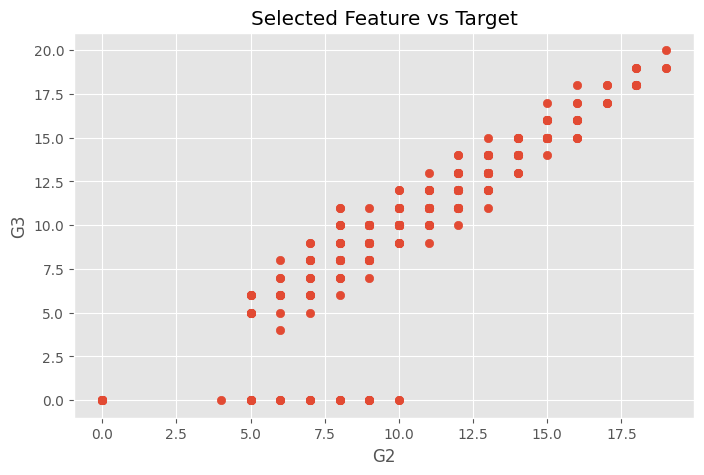

In [14]:
plt.figure(figsize=(8,5))
plt.scatter(X,y)

plt.xlabel("G2")
plt.ylabel("G3")

plt.title("Selected Feature vs Target")

plt.show()

# 🧠 Gradient Descent Implementation

In [15]:
X = X.reshape(-1)

m = 0
b = 0

lr = 0.001

epochs = 1000

n = len(X)

losses = []

for i in range(epochs):

    y_pred = m*X + b

    cost = (1/n)*np.sum((y-y_pred)**2)

    losses.append(cost)

    dm = (-2/n)*np.sum(X*(y-y_pred))
    db = (-2/n)*np.sum(y-y_pred)

    m = m - lr*dm
    b = b - lr*db

print("Slope:",m)
print("Intercept:",b)

Slope: 1.0034461250914046
Intercept: -0.20668730714334166


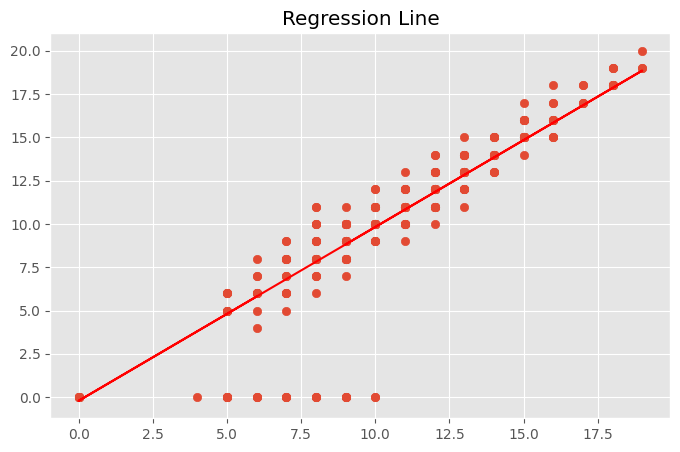

In [17]:
y_pred = m*X + b

plt.figure(figsize=(8,5))

plt.scatter(X,y)

plt.plot(X,y_pred,color='red')

plt.title("Regression Line")

plt.show()

# 📌 Conclusion

The Linear Regression model was successfully implemented using Gradient Descent from scratch.

Key Findings:

- G2 was found to be the strongest predictor of final grade.
- Gradient Descent minimized prediction error effectively.
- The model achieved a strong R² score.
- The relationship between G2 and G3 is highly linear.

# 🤖 Task 3: Loan Prediction using Logistic Regression

### ELabs Data Analysis Program

This project predicts loan approval status using a multivariate Logistic Regression model.

The notebook covers:

- Data Cleaning
- Missing Value Treatment
- Encoding
- Scaling
- Logistic Regression
- Model Evaluation
- Explainable AI using SHAP

In [20]:
!pip install shap

   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
    --------------------------------------- 0.5/38.1 MB 4.2 MB/s eta 0:00:09
   - -------------------------------------- 1.3/38.1 MB 3.1 MB/s eta 0:00:13
   - -------------------------------------- 1.8/38.1 MB 3.1 MB/s eta 0:00:12
   - -------------------------------------- 1.8/38.1 MB 3.1 MB/s eta 0:00:12
   - -------------------------------------- 1.8/38.1 MB 3.1 MB/s eta 0:00:12
   -- ------------------------------------- 2.4/38.1 MB 1.8 MB/s eta 0:00:20
   --- ------------------------------------ 2.9/38.1 MB 1.9 MB/s eta 0:00:19
   --- ------------------------------------ 3.4/38.1 MB 2.0 MB/s eta 0:00:18
   ---- ----------------------------------- 4.2/38.1 MB 2.2 MB/s eta 0:00:16
   ----- ---------------------------------- 5.0/38.1 MB 2.3 MB/s eta 0:00:15
   ------ --------------------------------- 5.8/38.1 MB 2.5 MB/s eta 0:00:14
   ------ --------------------------------- 6.3/38.1 MB 2.5 MB/s eta 0:00:13
   ---


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# 📂 Dataset Loading

The loan prediction dataset is loaded and inspected to understand its structure, attributes, and target variable.

In [23]:
import pandas as pd

df = pd.read_csv("train_u6lujuX_CVtuZ9i.csv")

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


# 🔍 Dataset Inspection

Understanding the dataset dimensions, column types, and statistical properties.

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [25]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [26]:
df.shape

(614, 13)

# 🧹 Missing Value Analysis

Before building a machine learning model, it is important to identify missing values and understand their distribution.

In [27]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

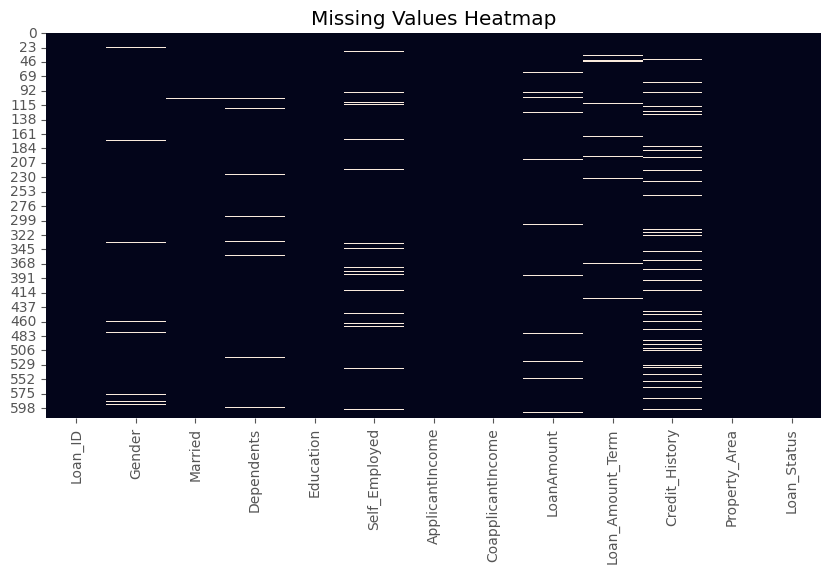

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")

plt.show()

# 🔧 Missing Value Treatment

Missing values are replaced using:

- Mode for categorical variables
- Median for numerical variables

This helps preserve dataset integrity without introducing significant bias.

In [30]:
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

df['Married'] = df['Married'].fillna(df['Married'].mode()[0])

df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])

df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())

df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])

df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

In [31]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

# 📊 Exploratory Data Analysis (EDA)

EDA helps identify patterns, trends, and relationships within the dataset before model building.

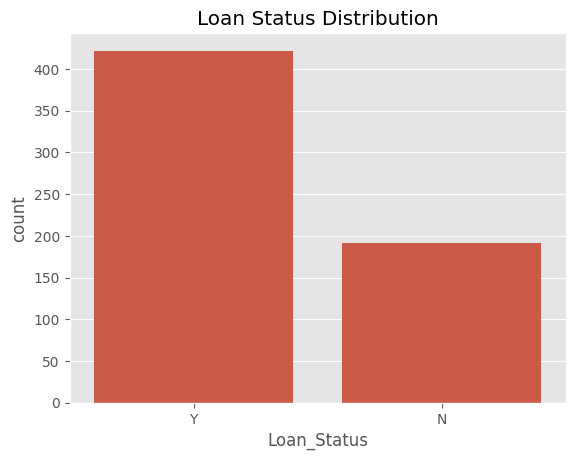

In [32]:
sns.countplot(x='Loan_Status', data=df)

plt.title("Loan Status Distribution")

plt.show()

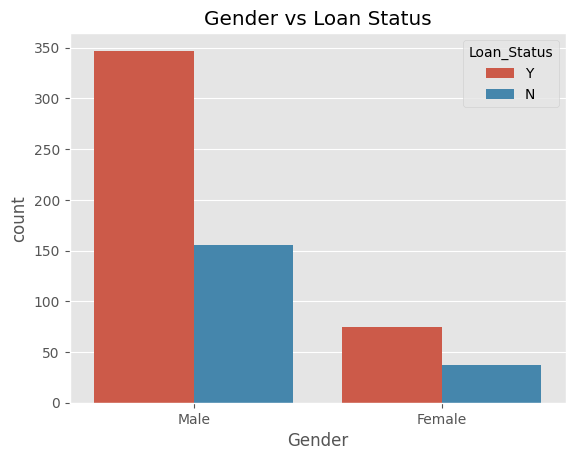

In [33]:
sns.countplot(x='Gender', hue='Loan_Status', data=df)

plt.title("Gender vs Loan Status")

plt.show()

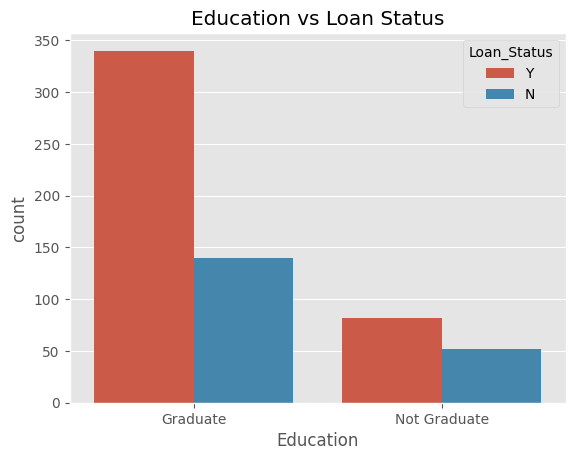

In [34]:
sns.countplot(x='Education', hue='Loan_Status', data=df)

plt.title("Education vs Loan Status")

plt.show()

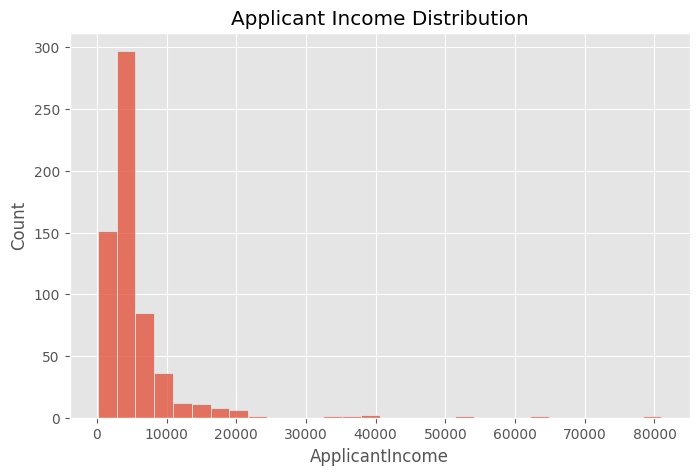

In [35]:
plt.figure(figsize=(8,5))

sns.histplot(df['ApplicantIncome'], bins=30)

plt.title("Applicant Income Distribution")

plt.show()

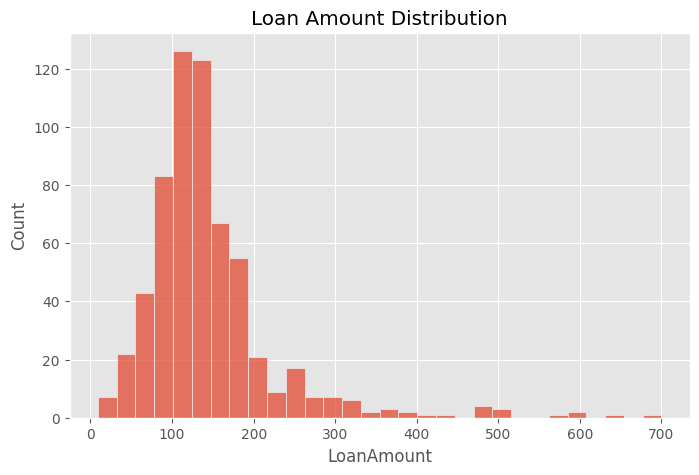

In [36]:
plt.figure(figsize=(8,5))

sns.histplot(df['LoanAmount'], bins=30)

plt.title("Loan Amount Distribution")

plt.show()

# 🔄 Feature Encoding

Machine learning algorithms require numerical inputs.

Categorical features are converted into numerical representations using Label Encoding.

In [37]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# 🔥 Correlation Analysis

Correlation analysis helps identify relationships between variables and understand which features influence loan approval decisions.

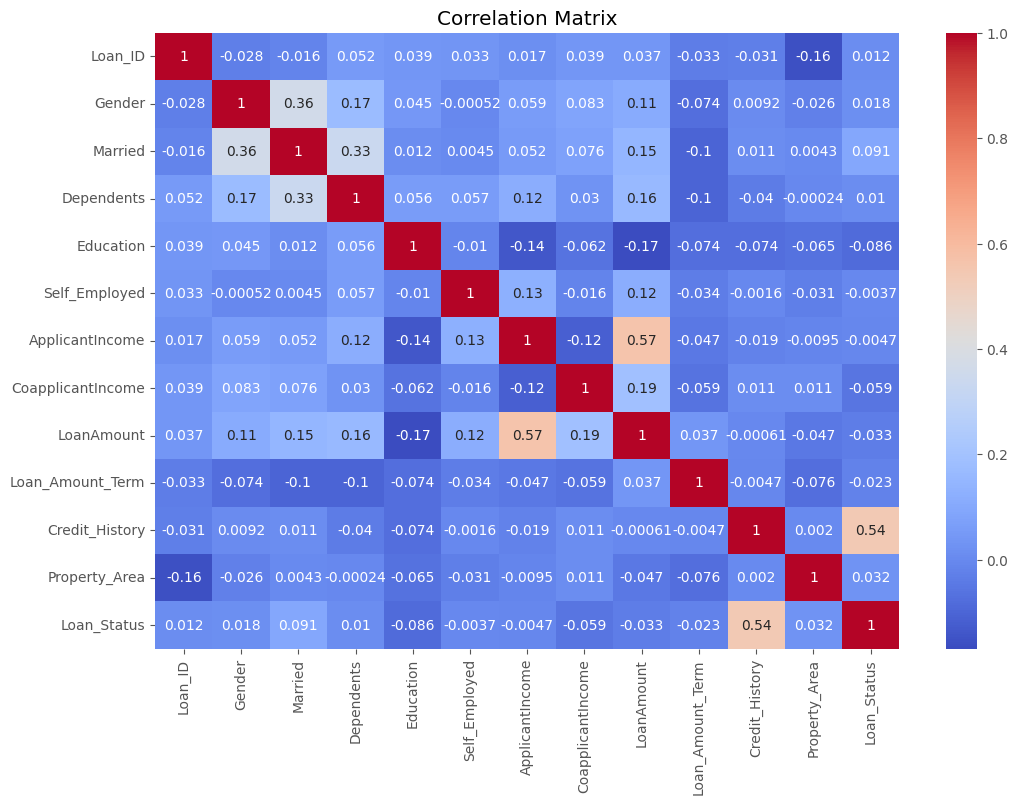

In [38]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")

plt.show()

In [39]:
X = df.drop(['Loan_Status','Loan_ID'], axis=1)

y = df['Loan_Status']

# ✂️ Train-Test Split

The dataset is divided into:

- 80% Training Data
- 20% Testing Data

to evaluate model generalization.

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ⚖️ Feature Scaling

Standardization is applied to normalize feature values and improve model performance.

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# 🤖 Logistic Regression Model

In [42]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [43]:
y_pred = model.predict(X_test)

# 📈 Model Evaluation

In [44]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy*100,2),"%")

Accuracy: 78.86 %


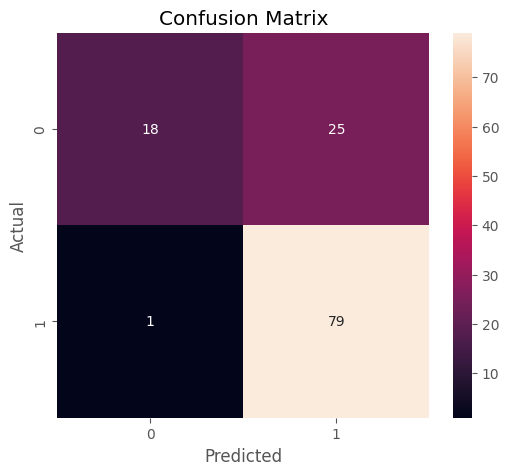

In [45]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [46]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



# 🧠 Explainable AI using SHAP

SHAP (SHapley Additive Explanations) helps understand which features contribute most toward loan approval predictions.

Background dataset has 491 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=491 when initializing the masker.


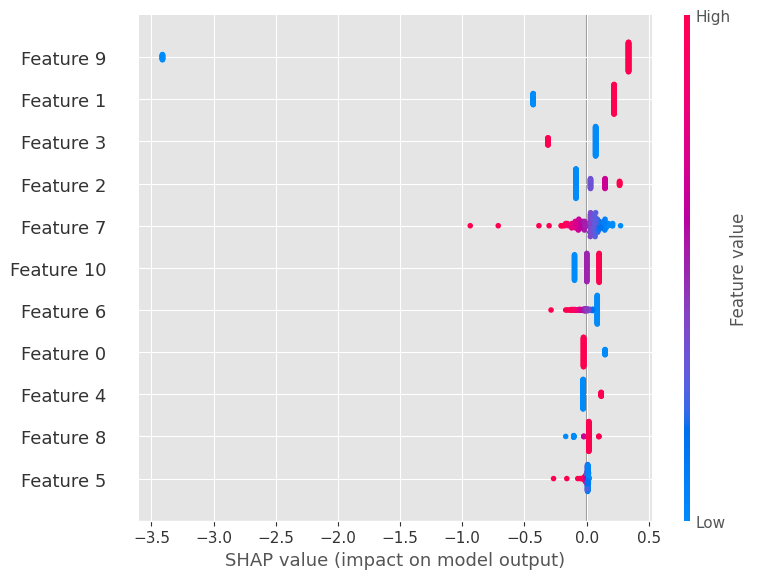

In [47]:
import shap

explainer = shap.LinearExplainer(model, X_train)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

# Conclusion

The Logistic Regression model was successfully implemented for loan prediction.

Key observations:

- Missing values were handled effectively.
- Feature scaling improved model performance.
- Logistic Regression achieved satisfactory classification accuracy.
- Confusion Matrix and Classification Report demonstrated strong predictive capability.
- SHAP explainability identified the most influential factors affecting loan approval decisions.

This project demonstrates a complete machine learning workflow involving preprocessing, feature engineering, classification, evaluation, and explainable AI.

# 🏏 IPL 2025 Performance Analytics & Predictive Modeling

## 📌 Project Overview

This project performs Exploratory Data Analysis (EDA) and Predictive Analytics on IPL 2025 player performance data.

The analysis focuses on:

- Batter Performance Analysis
- Bowler Performance Analysis
- Strike Rate Evaluation
- Wicket Taking Ability
- Economy Analysis
- Correlation Analysis
- Predictive Modeling

## 🎯 Objectives

- Perform Data Cleaning
- Conduct Exploratory Data Analysis
- Generate Visual Insights
- Build a Predictive Model
- Create a Power BI Dashboard

In [51]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

plt.style.use('ggplot')

# 📂 Dataset Loading

The IPL 2025 Batter and Bowler datasets are loaded for analysis.

In [52]:
batters = pd.read_csv("IPL2025Batters.csv")
bowlers = pd.read_csv("IPL2025Bowlers.csv")

In [53]:
batters.head()

,Player Name,Team,Runs,Matches,Inn,No,HS,AVG,BF,SR,100s,50s,4s,6s
0,Sai Sudharsan,GT,759,15,15,1,108*,54.21,486,156.17,1,6,88,21
1,Surya Kumar Yadav,MI,717,16,16,5,73*,65.18,427,167.91,0,5,69,38
2,Virat Kohli,RCB,657,15,15,3,73*,54.75,454,144.71,0,8,66,19
3,Shubman Gill,GT,650,15,15,2,93*,50.00,417,155.87,0,6,62,24
4,Mitchell Marsh,LSG,627,13,13,0,117,48.23,383,163.70,1,6,56,37


In [54]:
bowlers.head()

,Player Name,Team,WKT,MAT,INN,OVR,RUNS,BBI,AVG,ECO,SR,4W,5W
0,Prasidh Krishna,GT,25,15,15,59.0,488,41/4,19.52,8.27,14.16,1,0
1,Noor Ahmad,CSK,24,14,14,50.0,408,18/4,17.00,8.16,12.50,2,0
2,Josh Hazlewood,RCB,22,12,12,44.0,386,33/4,17.54,8.77,12.00,1,0
3,Trent Boult,MI,22,16,16,57.4,517,26/4,23.50,8.96,15.72,1,0
4,Arshdeep Singh,PBKS,21,17,16,58.2,518,16/3,24.66,8.88,16.66,0,0


# 🔍 Dataset Understanding

Understanding dataset dimensions, columns, and data types.

In [55]:
print("Batters Shape:", batters.shape)
print("Bowlers Shape:", bowlers.shape)

Batters Shape: (156, 14)
Bowlers Shape: (108, 13)


In [56]:
batters.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Player Name  156 non-null    object 
 1   Team         156 non-null    object 
 2   Runs         156 non-null    int64  
 3   Matches      156 non-null    int64  
 4   Inn          156 non-null    int64  
 5   No           156 non-null    int64  
 6   HS           156 non-null    object 
 7   AVG          156 non-null    object 
 8   BF           156 non-null    int64  
 9   SR           156 non-null    float64
 10  100s         156 non-null    int64  
 11  50s          156 non-null    int64  
 12  4s           156 non-null    int64  
 13  6s           156 non-null    int64  
dtypes: float64(1), int64(9), object(4)
memory usage: 17.2+ KB


In [57]:
bowlers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Player Name  108 non-null    object 
 1   Team         108 non-null    object 
 2   WKT          108 non-null    int64  
 3   MAT          108 non-null    int64  
 4   INN          108 non-null    int64  
 5   OVR          108 non-null    float64
 6   RUNS         108 non-null    int64  
 7   BBI          108 non-null    object 
 8   AVG          108 non-null    float64
 9   ECO          108 non-null    float64
 10  SR           108 non-null    float64
 11  4W           108 non-null    int64  
 12  5W           108 non-null    int64  
dtypes: float64(4), int64(6), object(3)
memory usage: 11.1+ KB


In [58]:
bowlers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Player Name  108 non-null    object 
 1   Team         108 non-null    object 
 2   WKT          108 non-null    int64  
 3   MAT          108 non-null    int64  
 4   INN          108 non-null    int64  
 5   OVR          108 non-null    float64
 6   RUNS         108 non-null    int64  
 7   BBI          108 non-null    object 
 8   AVG          108 non-null    float64
 9   ECO          108 non-null    float64
 10  SR           108 non-null    float64
 11  4W           108 non-null    int64  
 12  5W           108 non-null    int64  
dtypes: float64(4), int64(6), object(3)
memory usage: 11.1+ KB


In [59]:
print(batters.columns)
print(bowlers.columns)

Index(['Player Name', 'Team', 'Runs', 'Matches', 'Inn', 'No', 'HS', 'AVG',
       'BF', 'SR', '100s', '50s', '4s', '6s'],
      dtype='object')
Index(['Player Name', 'Team', 'WKT', 'MAT', 'INN', 'OVR', 'RUNS', 'BBI', 'AVG',
       'ECO', 'SR', '4W', '5W'],
      dtype='object')


# 📊 Statistical Summary

Descriptive statistics provide insights into player performance distributions.

In [60]:
batters.describe()

,Runs,Matches,Inn,No,BF,SR,100s,50s,4s,6s
count,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000
mean,161.320513,9.865385,7.153846,1.634615,105.673077,134.394103,0.057692,0.916667,14.391026,8.294872
std,180.352772,4.757455,4.810142,1.658163,112.191838,57.237148,0.233912,1.590124,17.778774,9.515500
min,1.000000,1.000000,1.000000,0.000000,1.000000,25.000000,0.000000,0.000000,0.000000,0.000000
25%,10.750000,6.000000,2.750000,0.000000,12.000000,100.000000,0.000000,0.000000,1.000000,0.000000
50%,93.500000,11.000000,6.000000,1.000000,63.500000,140.005000,0.000000,0.000000,7.000000,4.000000
75%,254.250000,14.000000,12.000000,3.000000,164.750000,162.707500,0.000000,1.000000,23.000000,14.000000
max,759.000000,17.000000,17.000000,7.000000,486.000000,400.000000,1.000000,8.000000,88.000000,40.000000


In [61]:
bowlers.describe()

,WKT,MAT,INN,OVR,RUNS,AVG,ECO,SR,4W,5W
count,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000
mean,7.675926,8.444444,7.675926,24.727778,233.796296,40.108519,9.875093,23.820463,0.148148,0.018519
std,6.294678,4.914851,4.767155,17.507130,155.708916,26.919800,1.592371,13.551808,0.428316,0.135445
min,1.000000,1.000000,1.000000,1.000000,13.000000,6.500000,6.500000,5.000000,0.000000,0.000000
25%,2.000000,4.000000,3.750000,10.000000,98.750000,24.330000,8.822500,15.712500,0.000000,0.000000
50%,6.000000,9.000000,7.000000,19.500000,185.500000,31.830000,9.705000,21.000000,0.000000,0.000000
75%,12.250000,13.000000,12.000000,41.625000,376.750000,47.250000,10.937500,25.767500,0.000000,0.000000
max,25.000000,17.000000,16.000000,59.000000,527.000000,175.000000,14.100000,85.000000,2.000000,1.000000


# 🧹 Missing Value Analysis

Checking for missing values before performing analysis.

In [62]:
batters.isnull().sum()

Player Name    0
Team           0
Runs           0
Matches        0
Inn            0
No             0
HS             0
AVG            0
BF             0
SR             0
100s           0
50s            0
4s             0
6s             0
dtype: int64

In [63]:
batters.isnull().sum()

Player Name    0
Team           0
Runs           0
Matches        0
Inn            0
No             0
HS             0
AVG            0
BF             0
SR             0
100s           0
50s            0
4s             0
6s             0
dtype: int64

In [64]:
bowlers.isnull().sum()

Player Name    0
Team           0
WKT            0
MAT            0
INN            0
OVR            0
RUNS           0
BBI            0
AVG            0
ECO            0
SR             0
4W             0
5W             0
dtype: int64

# 📈 Exploratory Data Analysis

The following visualizations help understand batting and bowling performance patterns.

## 🏏 Top Run Scorers

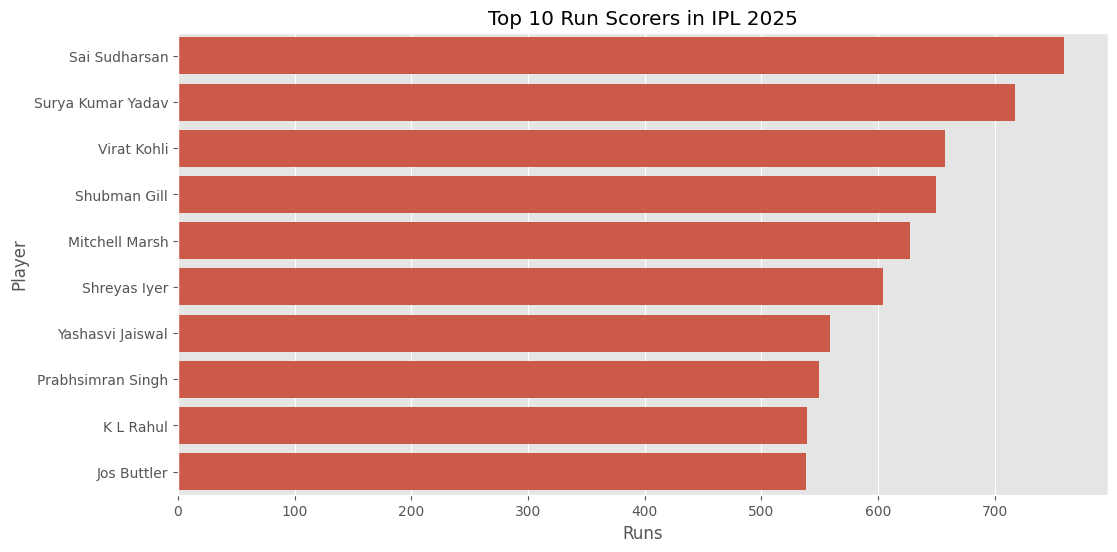

In [67]:
top_runs = batters.sort_values('Runs', ascending=False).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x='Runs',
    y='Player Name',
    data=top_runs
)

plt.title("Top 10 Run Scorers in IPL 2025")

plt.xlabel("Runs")
plt.ylabel("Player")

plt.show()

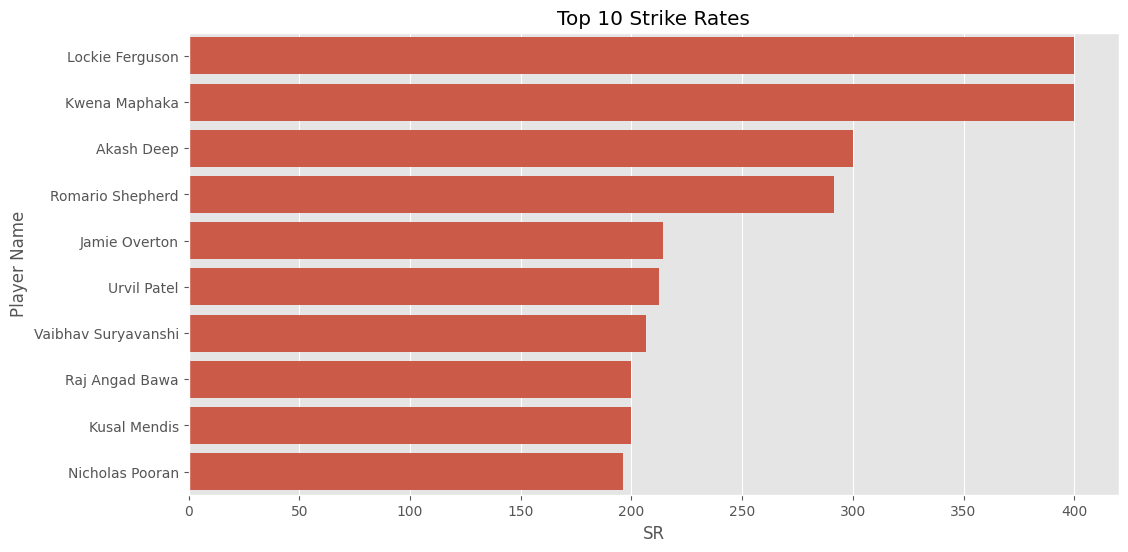

In [68]:
top_sr = batters.sort_values('SR', ascending=False).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x='SR',
    y='Player Name',
    data=top_sr
)

plt.title("Top 10 Strike Rates")

plt.show()

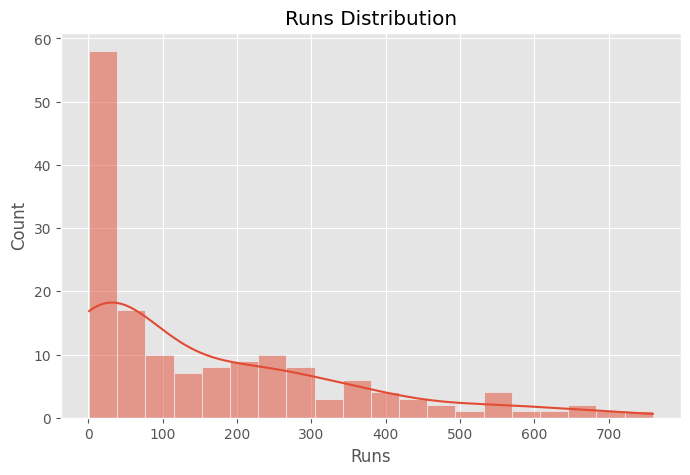

In [69]:
plt.figure(figsize=(8,5))

sns.histplot(
    batters['Runs'],
    bins=20,
    kde=True
)

plt.title("Runs Distribution")

plt.show()

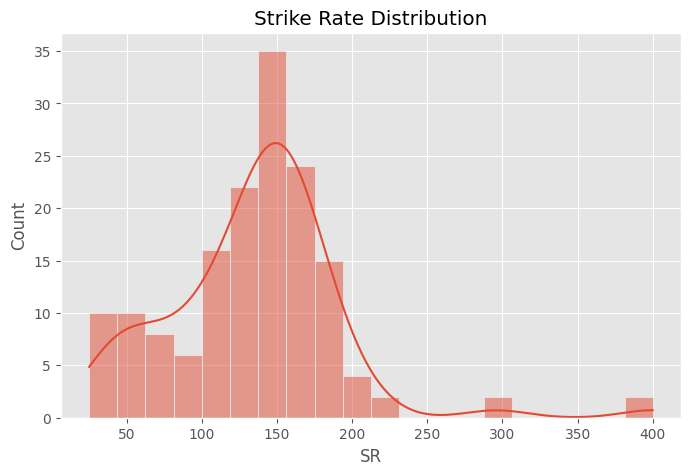

In [70]:
plt.figure(figsize=(8,5))

sns.histplot(
    batters['SR'],
    bins=20,
    kde=True
)

plt.title("Strike Rate Distribution")

plt.show()

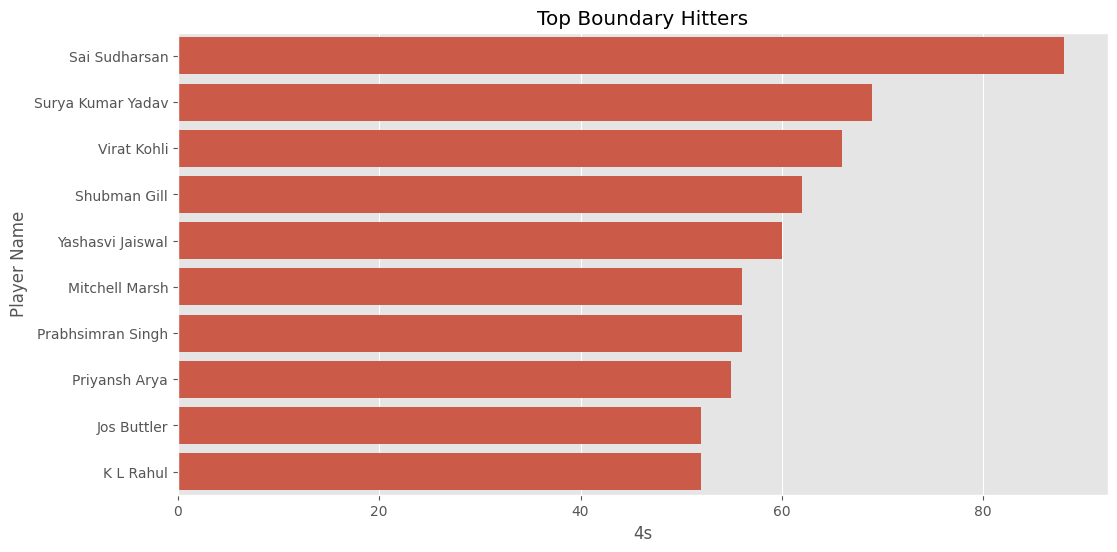

In [71]:
top_boundaries = batters.sort_values(
    '4s',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x='4s',
    y='Player Name',
    data=top_boundaries
)

plt.title("Top Boundary Hitters")

plt.show()

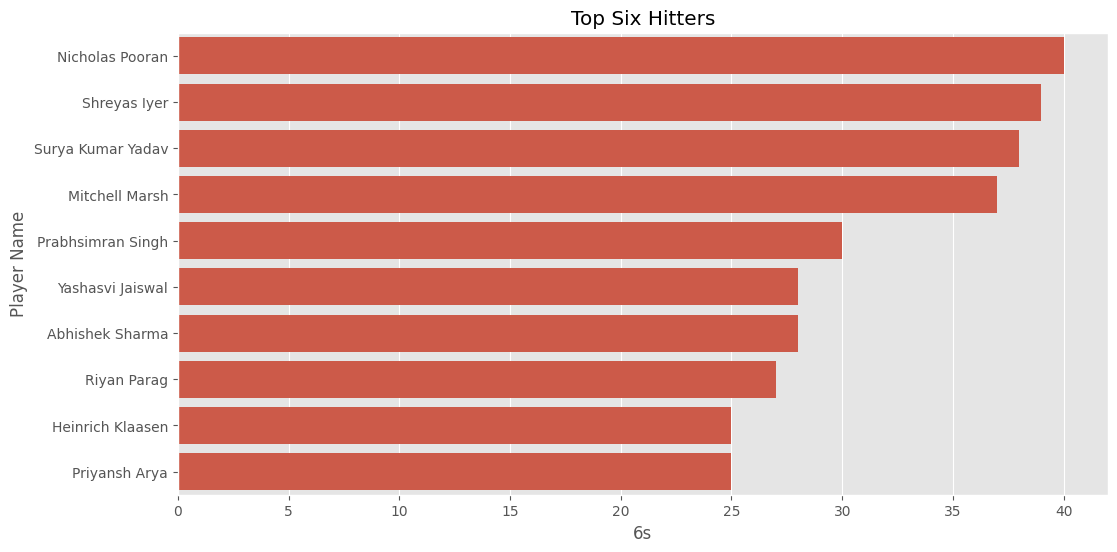

In [72]:
top_sixes = batters.sort_values(
    '6s',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x='6s',
    y='Player Name',
    data=top_sixes
)

plt.title("Top Six Hitters")

plt.show()

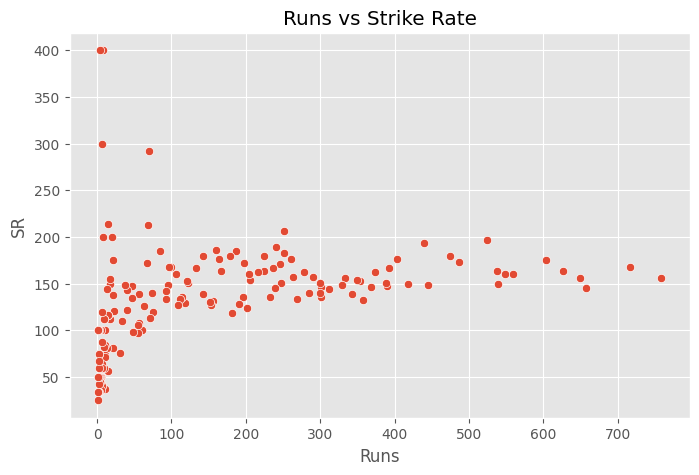

In [73]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Runs',
    y='SR',
    data=batters
)

plt.title("Runs vs Strike Rate")

plt.show()

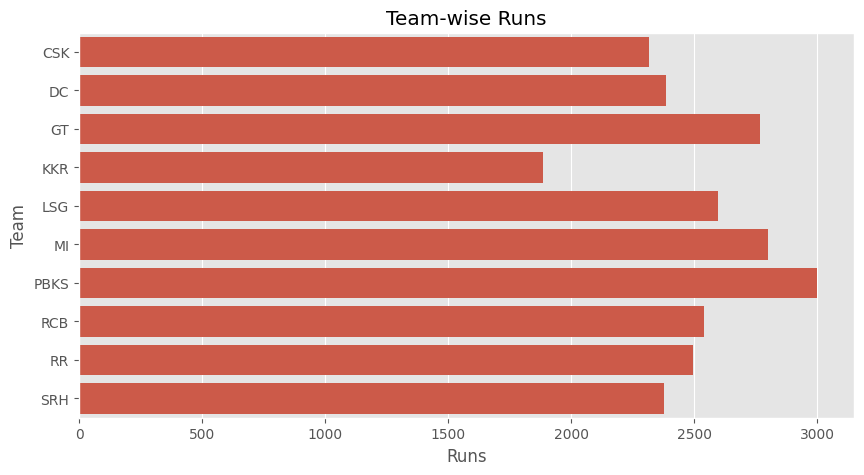

In [74]:
team_runs = batters.groupby(
    'Team'
)['Runs'].sum().reset_index()

plt.figure(figsize=(10,5))

sns.barplot(
    x='Runs',
    y='Team',
    data=team_runs
)

plt.title("Team-wise Runs")

plt.show()

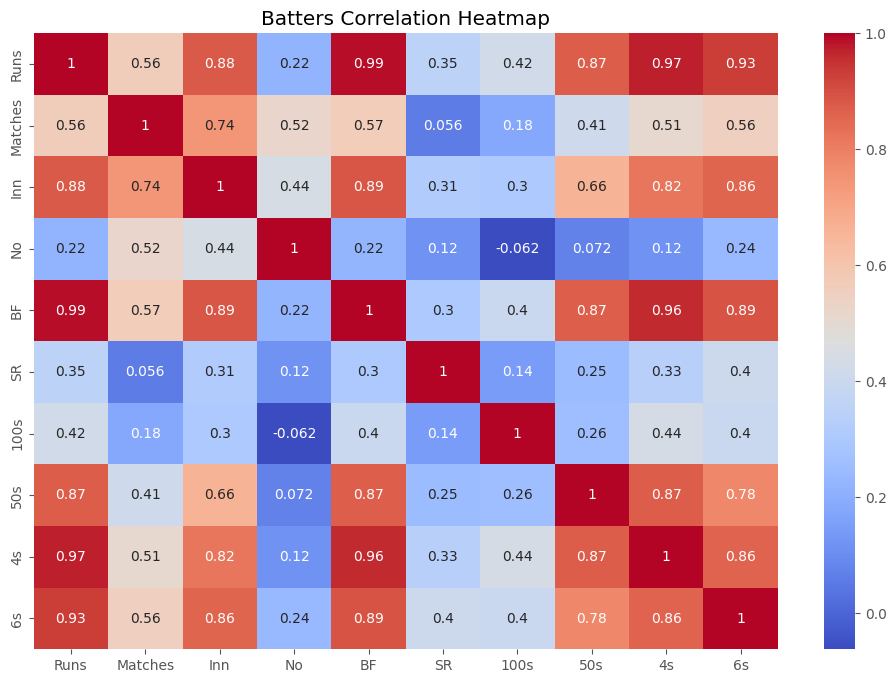

In [75]:
plt.figure(figsize=(12,8))

sns.heatmap(
    batters.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Batters Correlation Heatmap")

plt.show()

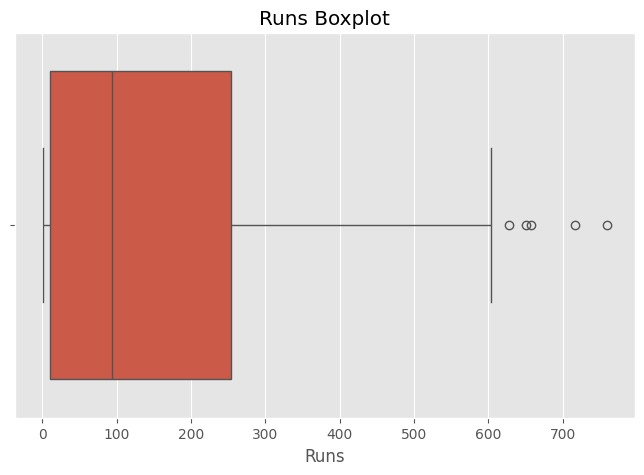

In [78]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=batters['Runs']
)

plt.title("Runs Boxplot")

plt.show()

# 🤖 Predictive Analysis

A Linear Regression model is developed to predict a player's Strike Rate based on Runs scored.

In [82]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [83]:
X = batters[['Runs']]

y = batters['SR']

In [84]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [85]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [86]:
predictions = model.predict(X_test)

In [87]:
print("R² Score:", r2_score(y_test, predictions))

R² Score: 0.21765806984772906


## 📈 Actual vs Predicted Strike Rate

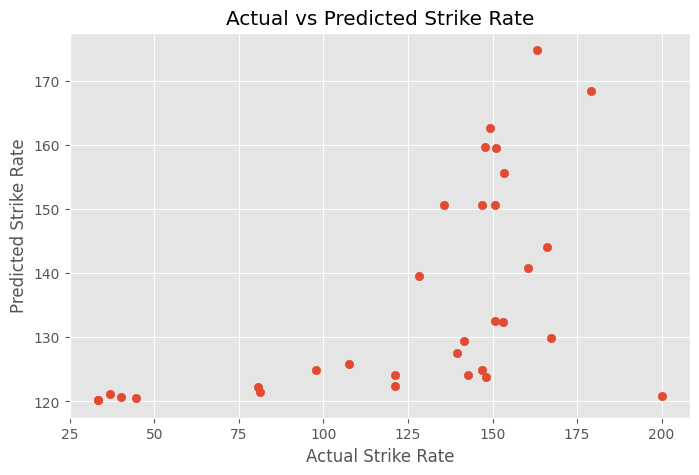

In [88]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    predictions
)

plt.xlabel("Actual Strike Rate")
plt.ylabel("Predicted Strike Rate")

plt.title("Actual vs Predicted Strike Rate")

plt.show()

# ✅ Conclusion

This project performed Exploratory Data Analysis and Predictive Analytics on IPL 2025 player performance data.

### Key Findings

- The top run scorers and wicket takers were identified.
- Strike rate and economy trends were analyzed.
- Team-wise batting and bowling performances were evaluated.
- Correlation analysis revealed important relationships among performance metrics.
- Predictive modeling demonstrated how batting statistics can be used to estimate strike rate.

### Skills Demonstrated

- Data Cleaning
- Exploratory Data Analysis (EDA)
- Data Visualization
- Statistical Analysis
- Machine Learning
- Sports Analytics
- Business Intelligence